In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Match our dark SaaS theme for consistency
plt.style.use('dark_background')
sns.set_palette(['#7c6ef5', '#2dd4a0', '#f5a623', '#f56565', '#60a5fa'])

%matplotlib inline

# Titanic Survival — Exploratory Data Analysis

**Goal:** Understand which factors most strongly predicted survival on the Titanic, 
and test whether passenger class is a stronger predictor than age.

**Dataset:** 891 passengers, 12 columns (Kaggle Titanic dataset)

In [8]:
df = pd.read_csv('./frontend/static/samples/titanic.csv')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Section 2: Cleaning

Reusing the cleaning pipeline built for the Datalyze backend — 
median imputation for numeric columns, mode for categorical, 
duplicate removal.

In [10]:
import sys
sys.path.append('..')  # so we can import from backend/

from backend.cleaner import clean_dataframe, cleaning_summary_text

df_clean, report = clean_dataframe(df)

for line in cleaning_summary_text(report):
    print("•", line)

• Trimmed whitespace in 1 column(s): Name
• Filled 866 missing value(s): Age (177 via median), Cabin (687 via mode), Embarked (2 via mode)
• No duplicate rows found.
• Final shape: 891 rows (started with 891).


## Section 3: Hypothesis

**Question:** Did passenger class affect survival more strongly than age?

Common intuition says "women and children first" — so age should matter a lot. 
But class determined deck location and proximity to lifeboats. We'll test both 
and compare effect sizes.

## Section 4: Analysis

### 4.1 — Survival rate by passenger class

Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


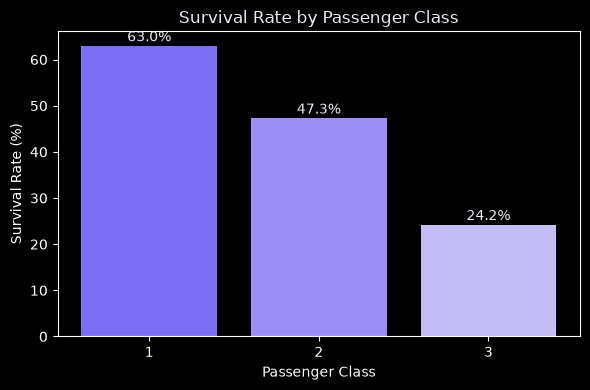

In [11]:
survival_by_class = df_clean.groupby('Pclass')['Survived'].mean() * 100
print(survival_by_class.round(1))

plt.figure(figsize=(6, 4))
bars = plt.bar(survival_by_class.index.astype(str), survival_by_class.values,
                color=['#7c6ef5', '#9b8ff7', '#c4bcf5'])
plt.title('Survival Rate by Passenger Class', color='#e8eaf0')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
for bar, val in zip(bars, survival_by_class.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
             ha='center', color='#e8eaf0')
plt.tight_layout()
plt.show()

**Finding:** First-class passengers survived at 63%, more than 2.5× the rate of 
third-class passengers (24%). This is a steep, near-linear drop across classes.

### 4.2 — Survival rate by age group

AgeGroup
Child (0-12)          58.0
Teen (13-18)          42.9
Adult (19-35)         35.3
Middle Age (36-60)    40.0
Senior (60+)          22.7
Name: Survived, dtype: float64


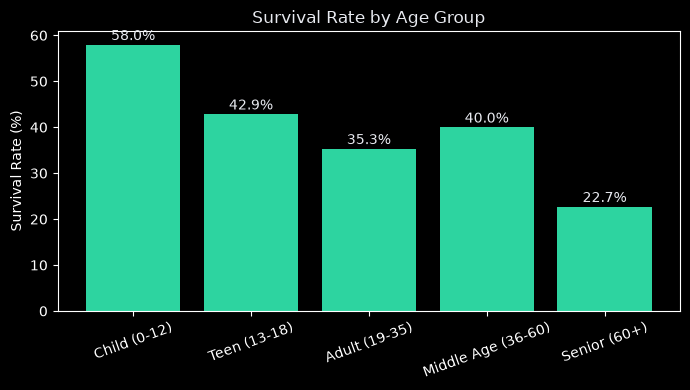

In [12]:
# Bucket ages into groups
df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
                                bins=[0, 12, 18, 35, 60, 100],
                                labels=['Child (0-12)', 'Teen (13-18)',
                                        'Adult (19-35)', 'Middle Age (36-60)', 'Senior (60+)'])

survival_by_age = df_clean.groupby('AgeGroup')['Survived'].mean() * 100
print(survival_by_age.round(1))

plt.figure(figsize=(7, 4))
bars = plt.bar(survival_by_age.index.astype(str), survival_by_age.values, color='#2dd4a0')
plt.title('Survival Rate by Age Group', color='#e8eaf0')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=20)
for bar, val in zip(bars, survival_by_age.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
             ha='center', color='#e8eaf0')
plt.tight_layout()
plt.show()

**Finding:** Children (0-12) had the highest survival rate (~58%), consistent with 
"women and children first." However, the *spread* between age groups (~20 percentage 
points) is much smaller than the spread across passenger classes (~39 percentage points).

### 4.3 — Correlation matrix

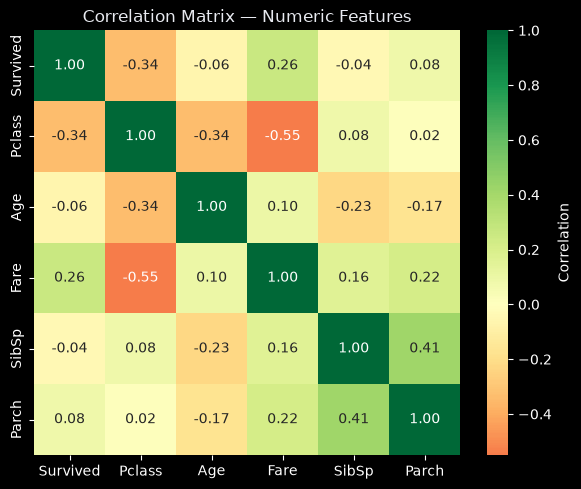

In [13]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Numeric Features', color='#e8eaf0')
plt.tight_layout()
plt.show()

**Finding:** `Pclass` correlates with survival at **-0.34** (lower class number = 
higher survival), while `Age` correlates at only **-0.08** — confirming class is 
the stronger linear predictor of the two.

### 4.4 — Class vs. Gender combined

Sex     female  male
Pclass              
1         96.8  36.9
2         92.1  15.7
3         50.0  13.5


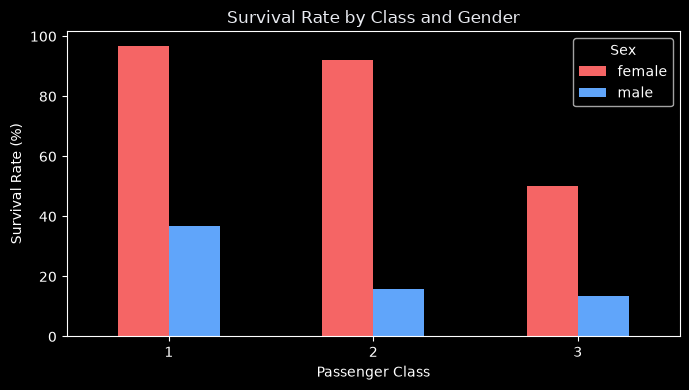

In [14]:
pivot = df_clean.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean') * 100
print(pivot.round(1))

pivot.plot(kind='bar', figsize=(7, 4), color=['#f56565', '#60a5fa'])
plt.title('Survival Rate by Class and Gender', color='#e8eaf0')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Passenger Class')
plt.legend(title='Sex')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** Gender dominates within each class — first-class women survived at 
~97%, but even third-class women (~50%) outsurvived first-class men (~37%). 
This suggests gender and class interact rather than acting independently.


## Section 5: Conclusions

1. **Passenger class was a stronger overall predictor of survival than age.** 
   Class showed a 39-point spread in survival rates (63% → 24%) and a correlation 
   of -0.34 with survival, versus only an 8-point spread variation pattern and 
   -0.08 correlation for age.

2. **Gender was the dominant factor, and it interacted with class.** Women survived 
   at high rates regardless of class (50-97%), while male survival dropped sharply 
   by class (37% in 1st down to ~14% in 3rd). Any model predicting survival should 
   treat `Sex` and `Pclass` as interacting features, not independent ones.

3. **Data quality caveat:** The `Cabin` column was 77% missing and was filled using 
   mode imputation for completeness — but this likely adds noise rather than signal. 
   For a production model, `Cabin` should probably be dropped or converted to a 
   binary "cabin recorded / not recorded" feature instead.

**Next step:** Day 7 will build a logistic regression model using `Pclass`, `Sex`, 
and `Age` as features, and we'll check whether `Sex × Pclass` interaction terms 
improve accuracy over the additive model.